In [6]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'axes.titlesize': 'small'})

import torch

import torchvision
from torchvision.utils import make_grid

from tqdm import tqdm

import os

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

print(f"GPU: {torch.cuda.is_available()}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device: ", device)

GPU: True
device:  cuda


In [25]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
from tqdm import tqdm
import cv2

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'axes.titlesize': 'small'})

class Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        car_path = Path(f"{root_dir}/cars")
        mask_path = Path(f"{root_dir}/masks")

        self.car_images = []
        self.mask_images = []
        
        self.car_images.extend([p.name for p in list(car_path.glob("*.png"))])
        self.mask_images.extend([p.name for p in list(mask_path.glob("*.png"))])

        self.car_images.extend([p.name for p in list(car_path.glob("*.jpg"))])
        self.mask_images.extend([p.name for p in list(mask_path.glob("*.jpg"))])

        self.car_images.extend([p.name for p in list(car_path.glob("*.jpeg"))])
        self.mask_images.extend([p.name for p in list(mask_path.glob("*.jpeg"))])

        self.car_images = sorted(self.car_images)
        self.mask_images = sorted(self.mask_images)

    def _resize_and_pad(self, image, mask):
        h, w = image.shape[:2]
        max_size = 512
        
        # Вычисляем новые размеры с сохранением пропорций
        if h > w:
            new_h = max_size
            new_w = int(w * max_size / h)
        else:
            new_w = max_size
            new_h = int(h * max_size / w)
        
        # Изменяем размер с разными интерполяциями
        image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4)
        mask = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
        
        # Создаем новые изображения с черным фоном
        padded_image = np.zeros((max_size, max_size, 3), dtype=image.dtype)
        padded_mask = np.zeros((max_size, max_size, 3), dtype=mask.dtype)
        
        # Вычисляем позиции для вставки
        top = (max_size - new_h) // 2
        left = (max_size - new_w) // 2
        
        # Вставляем изображения в центр
        padded_image[top:top+new_h, left:left+new_w] = image
        padded_mask[top:top+new_h, left:left+new_w] = mask
        
        return padded_image, padded_mask

    def __len__(self):
        return len(self.car_images)

    def __getitem__(self, idx):
        car_path = Path(self.root_dir, 'cars', self.car_images[idx])
        mask_path = Path(self.root_dir, 'masks', self.mask_images[idx]) 

        car_image = np.array(Image.open(car_path).convert('RGB'))
        mask_image = np.array(Image.open(mask_path).convert('RGB'))

        # Предобработка: изменение размера + паддинг
        car_image, mask_image = self._resize_and_pad(car_image, mask_image)

        # Применение преобразований
        if self.transform:
            augmented = self.transform(
                image=car_image.astype(np.float32)/255.0,
                #mask=mask_image.astype(np.float32)/255.0
                
                #image=car_image.astype(np.float32),
                mask=mask_image.astype(np.float32)
            )
            car_image = augmented['image']
            mask_image = augmented['mask']

            mask_image = mask_image.permute(2, 0, 1)
        else:
            car_image = car_image.astype(np.float32)/255.0
            #mask_image = mask_image.astype(np.float32)/255.0

            #car_image = car_image.astype(np.float32)
            mask_image = mask_image.astype(np.float32)
            
            car_image = torch.from_numpy(car_image).permute(2, 0, 1).float()
            mask_image = torch.from_numpy(mask_image).permute(2, 0, 1).float()
        
        return car_image, mask_image


transform = A.Compose([
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    #A.Rotate(limit=15, p=0.5),
    #A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], additional_targets={
        'image1': 'image'}, p=1)

transform_test = A.Compose([
    ToTensorV2(),
], additional_targets={
        'image1': 'image'}, p=1)

train_dataset = Dataset(root_dir='Car parts dataset/File1/', transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=1) # Для ускорения процесса обучения можно попробовать увеличить num_workers

test_dataset = Dataset(root_dir='Car parts dataset/File1/', transform=transform_test)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=1)

In [26]:
print(1)

1


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


tensor(255.) tensor(0.)


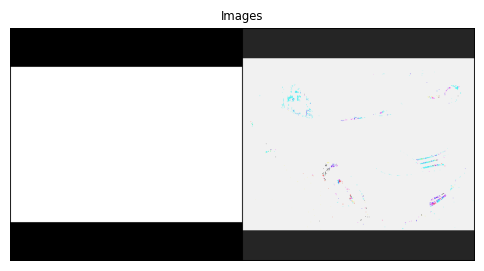

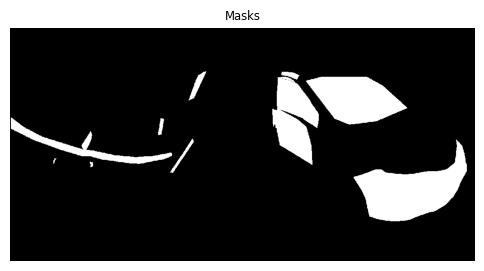

In [19]:
# import torch
# import torchvision
# import matplotlib.pyplot as plt

# # Функция для отображения батча
# def show_batch(images, masks=None, nrow=2):
#     """
#     images: torch.Tensor, форма [B, C, H, W]
#     masks:   torch.Tensor или None, форма [B, C, H, W]
#     nrow:    сколько изображений по ширине
#     """
#     # Собираем изображения в сетку
#     grid_img = torchvision.utils.make_grid(images, nrow=nrow, padding=2)
#     # Переносим каналы на последний индекс и конвертируем в NumPy
#     np_img = grid_img.permute(1, 2, 0).cpu().numpy()
    
#     plt.figure(figsize=(6,6))
#     plt.imshow(np_img)
#     plt.axis('off')
#     plt.title('Images')
    
#     # Если нужны маски:
#     if masks is not None:
#         grid_mask = torchvision.utils.make_grid(masks, nrow=nrow, padding=2)
#         np_mask = grid_mask.permute(1, 2, 0).cpu().numpy()
#         plt.figure(figsize=(6,6))
#         plt.imshow(np_mask)
#         plt.axis('off')
#         plt.title('Masks')
    
#     plt.show()

# # Пример использования в цикле
# for images, masks in train_dataloader:
#     # images — тензор [B, 3, H, W], values в [0,1]
#     # masks  — тензор [B, 3, H, W], values в [0,1]
#     print(torch.max(masks[0][0]), torch.min(masks[0][0]))
#     show_batch(images, masks, nrow=2)
#     break

ERROR: Unexpected bus error encountered in worker. This might be caused by insufficient shared memory (shm).
 

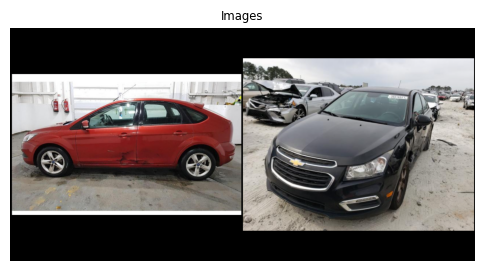

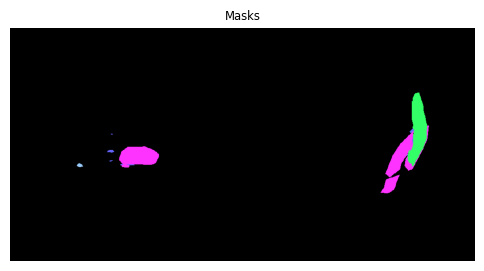

In [27]:
import torch
import torchvision
import matplotlib.pyplot as plt

def show_batch(images, masks=None, nrow=2):
    """
    images: torch.Tensor, форма [B, C, H, W], значения могут быть в [0,1] или [0,255]
    masks:  torch.Tensor или None, форма [B, C, H, W], тоже в [0,1] или [0,255]
    nrow:   сколько изображений по ширине
    """
    def prep(tensor):
        # переводим в float
        t = tensor.float().cpu()
        # если значения 0..255, нормализуем к 0..1
        if t.max() > 1.0:
            t = t / 255.0
        return t

    imgs = images
    grid_img = torchvision.utils.make_grid(imgs, nrow=nrow, padding=2)
    np_img = grid_img.permute(1, 2, 0).numpy()

    plt.figure(figsize=(6,6))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title('Images')

    if masks is not None:
        msks = prep(masks)
        grid_mask = torchvision.utils.make_grid(msks, nrow=nrow, padding=2)
        np_mask = grid_mask.permute(1, 2, 0).numpy()
        plt.figure(figsize=(6,6))
        plt.imshow(np_mask)
        plt.axis('off')
        plt.title('Masks')

    plt.show()


# Пример использования в цикле
for images, masks in train_dataloader:
    # допустим теперь images и masks в диапазоне 0–255
    show_batch(images, masks, nrow=2)
    break

In [21]:
# GRADED CELL: train_model
from skimage.metrics import mean_squared_error as mse

def train_model(model, train_dataloader, optimizer, criterion, scheduler, 
                num_epochs=200, checkpoints_path="./checkpoints", 
                use_grad_clip=True, save_checkpoints=True, load_last_checkpoint=True,
                save_epoch=1):
    
    # Создаем папку для чекпоинтов
    if save_checkpoints:
        PATH = checkpoints_path
        SAVE_EPOCH = save_epoch  
        os.makedirs(PATH, exist_ok = True)
        
    last_epoch = -1
    last_dict = None
    if load_last_checkpoint:
        for file_name in tqdm(list(os.listdir(PATH))):
            try:
                cur_dict = torch.load(os.path.join(PATH, file_name), map_location=torch.device('cpu'))
                if cur_dict['epoch'] > last_epoch:
                    last_epoch = cur_dict['epoch']
                    if last_dict is not None:
                        del last_dict
                        
                    last_dict = cur_dict
                else:
                    del cur_dict
            except:
                pass
            
        if last_dict is not None:
            model.load_state_dict(last_dict['model_state_dict'])
            optimizer.load_state_dict(last_dict['optimizer_state_dict'])
            scheduler.load_state_dict(last_dict['scheduler_state_dict'])
            last_epoch = last_dict['epoch']
            print(f'Загружен последний чекпоинт из эпохи {last_epoch}')
            del last_dict
    
    print("last_epoch:", last_epoch)

    # Цикл обучения
    for epoch in range(last_epoch + 1, num_epochs):
        total_loss = 0.0
        total_samples = 0 

        for inputs, targets in tqdm(train_dataloader, desc=f'Эпоха {epoch}'):
            optimizer.zero_grad()

            inputs = inputs.to(device)  
            targets = targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss.backward()
            
            if use_grad_clip:
                # Здесь нужно реализовать ограничение градиентов
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
                pass

            optimizer.step()
            
            total_loss += loss.item() * inputs.size(0)
            total_samples += inputs.size(0)

        avg_loss = total_loss / total_samples
        
        # Сохраняем чекпоинт каждые SAVE_EPOCH эпох
        if save_checkpoints and epoch % SAVE_EPOCH == 0:
            torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),
                    }, os.path.join(PATH, f"epoch_{epoch}.pth"))
    
        # Обновляем learning rate
        scheduler.step()
        print(f'Эпоха {epoch}, Loss: {avg_loss} LR: {scheduler.get_last_lr()[0]} Mean MSE: {np.mean(PSNRs)}')

In [7]:
from utils import get_scheduler
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",       
    encoder_weights="imagenet",    # !!!!!!!!
    in_channels=3,                 
    classes=8,                    
    activation=None,               
    decoder_channels=(256, 128, 64, 32, 16)  
)

torch.manual_seed(11)
model = model.to(device)

criterion = PSNRLoss() # !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
use_grad_clip = False
scheduler = get_scheduler(optimizer)

train_model(model, train_dataloader, optimizer, criterion, scheduler, num_epochs=25, checkpoints_path='./checkpoints/baseline')

NameError: name 'PSNRLoss' is not defined